In [1]:
!nvidia-smi
import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print("✅ GPU OK!")
else:
    print("❌ Không có GPU! Runtime → Change runtime type → T4 GPU")

Wed Apr 29 16:10:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install transformers==4.35.0 -q
!pip install lime -q
!pip install transformers-interpret==0.10.0 -q
!pip install torch scikit-learn pandas numpy matplotlib -q
print("✅ Cài xong! Tiếp tục Cell 3!")

✅ Cài xong! Tiếp tục Cell 3!


In [3]:
import os, gc, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification
)
from lime.lime_text import LimeTextExplainer
from transformers_interpret import SequenceClassificationExplainer
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('/content/outputs_xai', exist_ok=True)

print(f"✅ Import xong!")
print(f"   Device: {device}")
print("Tiếp tục Cell 4!")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


✅ Import xong!
   Device: cuda
Tiếp tục Cell 4!


In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load RoBERTa Balanced (model chính cho XAI — bài báo Section 5)
MODEL_PATH = '/content/drive/MyDrive/Stage2_models/roberta-base_Balanced.pt'

print("⏳ Loading tokenizer và model...")
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model     = RobertaForSequenceClassification.from_pretrained(
                'roberta-base', num_labels=2)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model loaded!")
print(f"   Parameters: {total_params/1e6:.1f}M")
print(f"   Device    : {device}")
print("Tiếp tục Cell 5!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Loading tokenizer và model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded!
   Parameters: 124.6M
   Device    : cuda
Tiếp tục Cell 5!


In [5]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df  = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

def preprocess_text(text):
    """Algorithm 1 — bài báo ExplainableDetector"""
    text = str(text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.replace('\r', ' ').strip()
    words, seen = text.split(), []
    for w in words:
        if w not in seen:
            seen.append(w)
    return ' '.join(seen)

df['message_clean'] = df['message'].apply(preprocess_text)
df['label_num']     = df['label'].map({'ham': 0, 'spam': 1})

# Lấy mẫu SPAM và HAM để giải thích
spam_samples = df[df['label']=='spam']['message_clean'].tolist()
ham_samples  = df[df['label']=='ham']['message_clean'].tolist()

print(f"✅ Dataset loaded: {len(df)} mẫu")
print(f"   Spam samples: {len(spam_samples)}")
print(f"   Ham  samples: {len(ham_samples)}")

# 4 tin nhắn dùng cho XAI (giống bài báo: 2 spam + 2 ham)
sms_spam_1 = spam_samples[0]
sms_spam_2 = spam_samples[1]
sms_ham_1  = ham_samples[0]
sms_ham_2  = ham_samples[1]

print(f"\n📱 SMS SPAM 1: {sms_spam_1[:80]}...")
print(f"📱 SMS SPAM 2: {sms_spam_2[:80]}...")
print(f"📱 SMS HAM  1: {sms_ham_1[:80]}...")
print(f"📱 SMS HAM  2: {sms_ham_2[:80]}...")
print("\nTiếp tục Cell 6!")

✅ Dataset loaded: 5572 mẫu
   Spam samples: 747
   Ham  samples: 4825

📱 SMS SPAM 1: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005 Text 87121 re...
📱 SMS SPAM 2: FreeMsg Hey there darling it s been 3 week now and no word back I d like some fu...
📱 SMS HAM  1: Go until jurong point crazy Available only in bugis n great world la e buffet Ci...
📱 SMS HAM  2: Ok lar Joking wif u oni...

Tiếp tục Cell 6!


In [6]:
def predict_proba(texts):
    """
    Hàm predict cho LIME — trả về xác suất [ham, spam]
    LIME cần hàm này để perturb và giải thích
    """
    probs = []
    for text in texts:
        enc = tokenizer(
            text,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)

        with torch.no_grad():
            output = model(input_ids=input_ids,
                           attention_mask=attention_mask)
            prob = F.softmax(output.logits, dim=1)
            probs.append(prob.cpu().numpy()[0])

    return np.array(probs)

# Test thử
test_prob = predict_proba([sms_spam_1])
print(f"✅ predict_proba hoạt động!")
print(f"   Test spam_1: ham={test_prob[0][0]:.4f}, spam={test_prob[0][1]:.4f}")
print(f"   → Predicted: {'SPAM' if test_prob[0][1] > 0.5 else 'HAM'}")
print("\nTiếp tục Cell 7!")

✅ predict_proba hoạt động!
   Test spam_1: ham=0.0000, spam=1.0000
   → Predicted: SPAM

Tiếp tục Cell 7!


In [7]:
# ============================================================
# LIME Explainer — bài báo dùng LimeTextExplainer
# num_features=15 (theo bài báo Section 5)
# class_names=['ham', 'spam']
# ============================================================

explainer = LimeTextExplainer(
    class_names=['ham', 'spam'],
    random_state=42
)

print("✅ LimeTextExplainer khởi tạo xong!")
print("   class_names : ['ham', 'spam']")
print("   num_features: 15 (theo bài báo)")
print("\nTiếp tục Cell 8!")

✅ LimeTextExplainer khởi tạo xong!
   class_names : ['ham', 'spam']
   num_features: 15 (theo bài báo)

Tiếp tục Cell 8!


In [8]:
def print_lime_table(exp, label_idx, sms_text, title):
    """
    In bảng positive/negative coefficients như Table 9-12 bài báo
    label_idx: 1=spam, 0=ham
    """
    coefs = exp.as_list(label=label_idx)

    positive = [(w, v) for w, v in coefs if v > 0]
    negative = [(w, v) for w, v in coefs if v < 0]

    # Sắp xếp theo giá trị tuyệt đối giảm dần
    positive.sort(key=lambda x: abs(x[1]), reverse=True)
    negative.sort(key=lambda x: abs(x[1]), reverse=True)

    print(f"\n{'='*65}")
    print(f"  {title}")
    print(f"  SMS: {sms_text[:70]}...")
    print(f"{'='*65}")
    print(f"  {'POSITIVE COEFFICIENTS':<32} {'NEGATIVE COEFFICIENTS'}")
    print(f"  {'-'*60}")
    print(f"  {'Word':<20} {'Value':>10}   {'Word':<20} {'Value':>10}")
    print(f"  {'-'*60}")

    max_rows = max(len(positive), len(negative))
    for i in range(max_rows):
        p_word  = f"'{positive[i][0]}'"  if i < len(positive) else ''
        p_val   = f"{positive[i][1]:.4f}" if i < len(positive) else ''
        n_word  = f"'{negative[i][0]}'"  if i < len(negative) else ''
        n_val   = f"{negative[i][1]:.4f}" if i < len(negative) else ''
        print(f"  {p_word:<20} {p_val:>10}   {n_word:<20} {n_val:>10}")

    print(f"{'='*65}")
    return positive, negative


def plot_lime_explanation(exp, label_idx, sms_text, title, save_path):
    """
    Vẽ bar chart LIME như Figure 10/11 trong bài báo
    """
    coefs = exp.as_list(label=label_idx)
    coefs.sort(key=lambda x: x[1])  # sắp xếp để hiển thị đẹp

    words  = [c[0] for c in coefs]
    values = [c[1] for c in coefs]
    colors = ['#ff6b6b' if v < 0 else '#51cf66' for v in values]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(words, values, color=colors, edgecolor='black',
                   linewidth=0.5, height=0.7)

    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient Value', fontsize=11)
    ax.set_title(
        f'Local explanation for class {"spam" if label_idx==1 else "ham"}\n{title}',
        fontsize=11, fontweight='bold'
    )

    # Legend
    pos_patch = mpatches.Patch(color='#51cf66', label='Positive (supports class)')
    neg_patch = mpatches.Patch(color='#ff6b6b', label='Negative (against class)')
    ax.legend(handles=[pos_patch, neg_patch], fontsize=9)

    # Highlight text box
    ax.text(0.01, 0.01, f'SMS: "{sms_text[:60]}..."',
            transform=ax.transAxes, fontsize=7,
            style='italic', color='gray',
            verticalalignment='bottom')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {save_path}")

print("✅ Helper functions sẵn sàng! Tiếp tục Cell 9!")

✅ Helper functions sẵn sàng! Tiếp tục Cell 9!


📱 Đang giải thích SMS SPAM 1:
   'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005 Text 87121 receive question std txt rate T C s apply 08452810075over18'


  TABLE 9 — LIME Coefficients: SMS SPAM 1
  SMS: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005 Tex...
  POSITIVE COEFFICIENTS            NEGATIVE COEFFICIENTS
  ------------------------------------------------------------
  Word                      Value   Word                      Value
  ------------------------------------------------------------
  '87121'                  0.0409   'May'                   -0.0133
  'txt'                    0.0280   'C'                     -0.0132
  '08452810075over18'      0.0273   'wkly'                  -0.0131
  '21st'                   0.0215                                  
  'apply'                  0.0214                                  
  'Free'                   0.0212                                  
  'entry'                  0.0196          

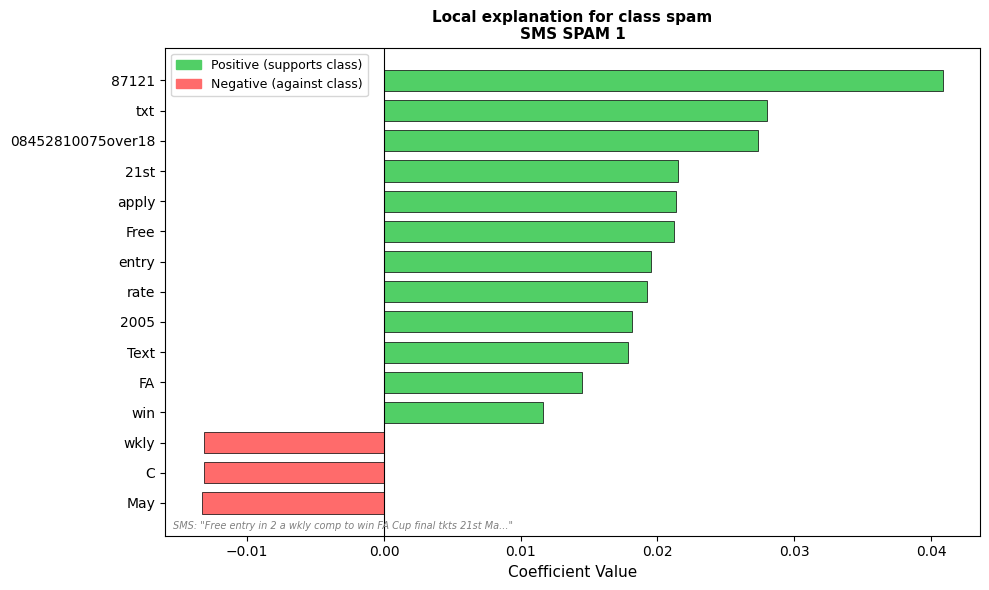

✅ Saved: /content/outputs_xai/fig10ab_lime_spam1.png

⏭️ Tiếp tục Cell 10!


In [9]:
# ============================================================
# LIME — SMS SPAM 1 (Figure 10a + Table 9)
# num_features=15 theo bài báo Section 5
# ============================================================
print(f"📱 Đang giải thích SMS SPAM 1:")
print(f"   '{sms_spam_1}'\n")

exp_spam1 = explainer.explain_instance(
    sms_spam_1,
    predict_proba,
    num_features=15,
    top_labels=2,
    num_samples=500    # giảm xuống 500 để nhanh hơn, vẫn đủ chính xác
)

# In bảng (Table 9)
pos1, neg1 = print_lime_table(
    exp_spam1, label_idx=1,
    sms_text=sms_spam_1,
    title="TABLE 9 — LIME Coefficients: SMS SPAM 1"
)

# Vẽ chart (Figure 10a + 10b)
plot_lime_explanation(
    exp_spam1, label_idx=1,
    sms_text=sms_spam_1,
    title="SMS SPAM 1",
    save_path='/content/outputs_xai/fig10ab_lime_spam1.png'
)
print("\n⏭️ Tiếp tục Cell 10!")

📱 Đang giải thích SMS SPAM 2:
   'FreeMsg Hey there darling it s been 3 week now and no word back I d like some fun you up for still Tb ok XxX std chgs to send 1 50 rcv'


  TABLE 10 — LIME Coefficients: SMS SPAM 2
  SMS: FreeMsg Hey there darling it s been 3 week now and no word back I d li...
  POSITIVE COEFFICIENTS            NEGATIVE COEFFICIENTS
  ------------------------------------------------------------
  Word                      Value   Word                      Value
  ------------------------------------------------------------
  'FreeMsg'                0.2374   'to'                    -0.0777
  '50'                     0.1710   'back'                  -0.0555
  '1'                      0.1362   'd'                     -0.0493
  'XxX'                    0.1154                                  
  'fun'                    0.1135                                  
  'rcv'                    0.0952                                  
  'chgs'                   0.0874            

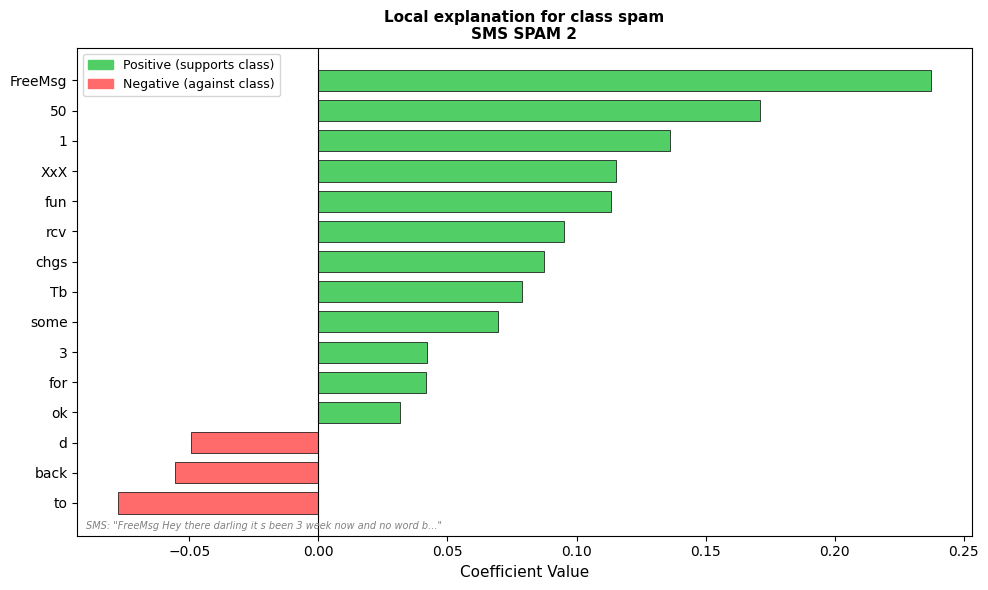

✅ Saved: /content/outputs_xai/fig10cd_lime_spam2.png

⏭️ Tiếp tục Cell 11!


In [10]:
print(f"📱 Đang giải thích SMS SPAM 2:")
print(f"   '{sms_spam_2}'\n")

exp_spam2 = explainer.explain_instance(
    sms_spam_2,
    predict_proba,
    num_features=15,
    top_labels=2,
    num_samples=500
)

# In bảng (Table 10)
pos2, neg2 = print_lime_table(
    exp_spam2, label_idx=1,
    sms_text=sms_spam_2,
    title="TABLE 10 — LIME Coefficients: SMS SPAM 2"
)

# Vẽ chart (Figure 10c + 10d)
plot_lime_explanation(
    exp_spam2, label_idx=1,
    sms_text=sms_spam_2,
    title="SMS SPAM 2",
    save_path='/content/outputs_xai/fig10cd_lime_spam2.png'
)
print("\n⏭️ Tiếp tục Cell 11!")

📱 Đang giải thích SMS HAM 1:
   'Go until jurong point crazy Available only in bugis n great world la e buffet Cine there got amore wat'


  TABLE 11 — LIME Coefficients: SMS HAM 1
  SMS: Go until jurong point crazy Available only in bugis n great world la e...
  POSITIVE COEFFICIENTS            NEGATIVE COEFFICIENTS
  ------------------------------------------------------------
  Word                      Value   Word                      Value
  ------------------------------------------------------------
  'crazy'                  0.0000   'Cine'                  -0.0000
  'there'                  0.0000   'Available'             -0.0000
  'bugis'                  0.0000   'in'                    -0.0000
  'great'                  0.0000   'only'                  -0.0000
  'amore'                  0.0000   'point'                 -0.0000
  'n'                      0.0000   'Go'                    -0.0000
  'la'                     0.0000                                  
  'wat'    

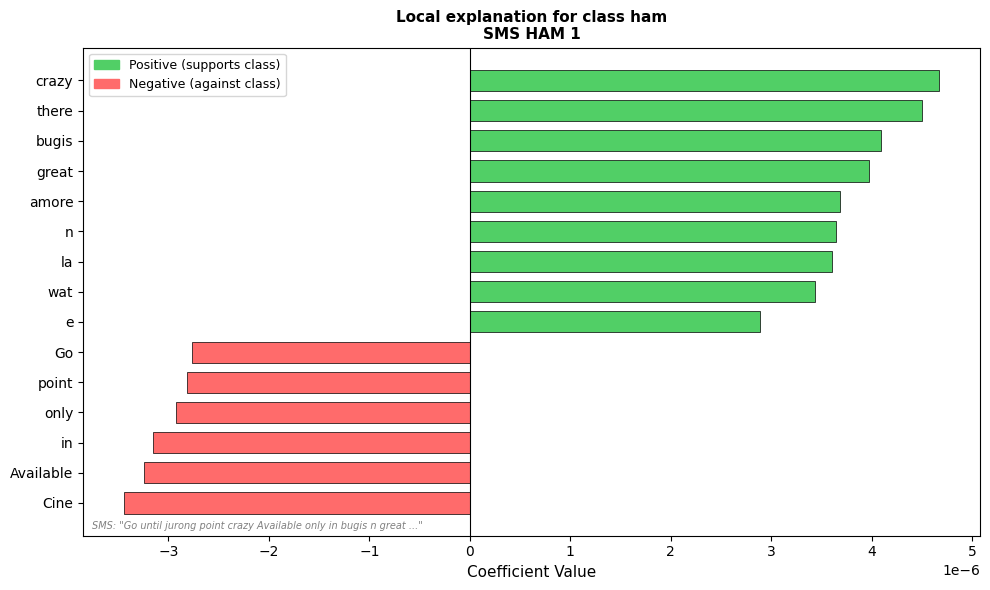

✅ Saved: /content/outputs_xai/fig11ab_lime_ham1.png

⏭️ Tiếp tục Cell 12!


In [11]:
print(f"📱 Đang giải thích SMS HAM 1:")
print(f"   '{sms_ham_1}'\n")

exp_ham1 = explainer.explain_instance(
    sms_ham_1,
    predict_proba,
    num_features=15,
    top_labels=2,
    num_samples=500
)

# In bảng (Table 11)
pos3, neg3 = print_lime_table(
    exp_ham1, label_idx=0,
    sms_text=sms_ham_1,
    title="TABLE 11 — LIME Coefficients: SMS HAM 1"
)

# Vẽ chart (Figure 11a + 11b)
plot_lime_explanation(
    exp_ham1, label_idx=0,
    sms_text=sms_ham_1,
    title="SMS HAM 1",
    save_path='/content/outputs_xai/fig11ab_lime_ham1.png'
)
print("\n⏭️ Tiếp tục Cell 12!")

📱 Đang giải thích SMS HAM 2:
   'Ok lar Joking wif u oni'


  TABLE 12 — LIME Coefficients: SMS HAM 2
  SMS: Ok lar Joking wif u oni...
  POSITIVE COEFFICIENTS            NEGATIVE COEFFICIENTS
  ------------------------------------------------------------
  Word                      Value   Word                      Value
  ------------------------------------------------------------
  'oni'                    0.0000                                  
  'wif'                    0.0000                                  
  'u'                      0.0000                                  
  'Joking'                 0.0000                                  
  'Ok'                     0.0000                                  
  'lar'                    0.0000                                  


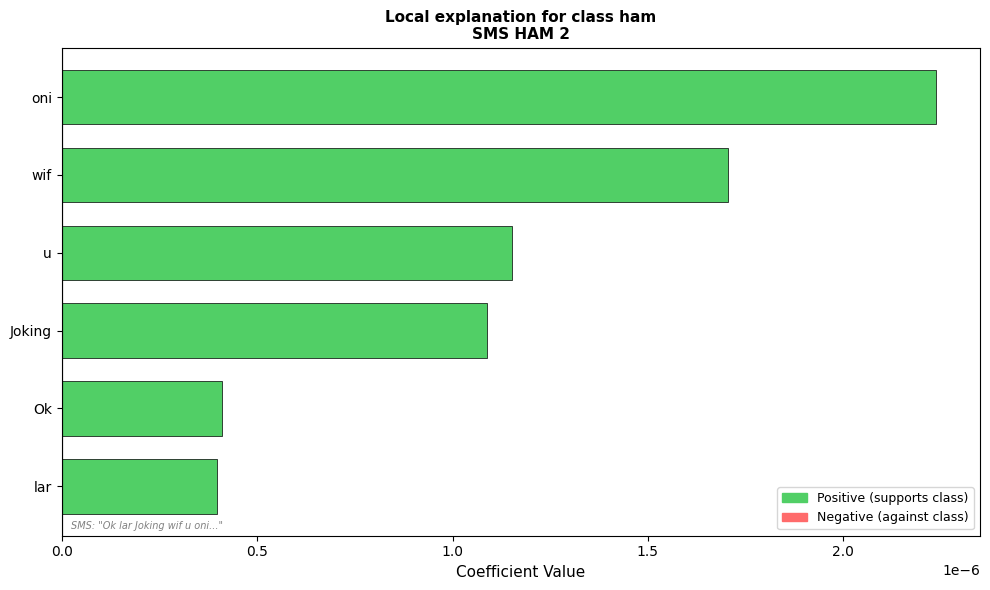

✅ Saved: /content/outputs_xai/fig11cd_lime_ham2.png

⏭️ Tiếp tục Cell 13!


In [12]:
print(f"📱 Đang giải thích SMS HAM 2:")
print(f"   '{sms_ham_2}'\n")

exp_ham2 = explainer.explain_instance(
    sms_ham_2,
    predict_proba,
    num_features=15,
    top_labels=2,
    num_samples=500
)

# In bảng (Table 12)
pos4, neg4 = print_lime_table(
    exp_ham2, label_idx=0,
    sms_text=sms_ham_2,
    title="TABLE 12 — LIME Coefficients: SMS HAM 2"
)

# Vẽ chart (Figure 11c + 11d)
plot_lime_explanation(
    exp_ham2, label_idx=0,
    sms_text=sms_ham_2,
    title="SMS HAM 2",
    save_path='/content/outputs_xai/fig11cd_lime_ham2.png'
)
print("\n⏭️ Tiếp tục Cell 13!")

In [13]:
# ============================================================
# TRANSFORMERS INTERPRET — bài báo dùng SequenceClassificationExplainer
# Tương ứng Figure 12/13 + Table 13-16
# ============================================================

cls_explainer = SequenceClassificationExplainer(
    model,
    tokenizer
)

def print_transformer_interpret_table(attributions, sms_text, true_label, pred_label, title):
    """
    In bảng word attributions như Table 13-16 bài báo
    Positive = ủng hộ predicted class
    Negative = chống lại predicted class
    """
    # Lọc bỏ special tokens [CLS], [SEP], <s>, </s>
    special = {'<s>', '</s>', '[CLS]', '[SEP]', '<pad>', '[PAD]'}
    filtered = [(w, v) for w, v in attributions
                if w not in special and w.strip()]

    positive = sorted([(w,v) for w,v in filtered if v > 0],
                      key=lambda x: abs(x[1]), reverse=True)
    negative = sorted([(w,v) for w,v in filtered if v < 0],
                      key=lambda x: abs(x[1]), reverse=True)

    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"  True Label: {true_label} | Predicted: {pred_label}")
    print(f"  SMS: {sms_text[:65]}...")
    print(f"{'='*70}")
    print(f"  {'POSITIVE COEFFICIENTS':<35} {'NEGATIVE COEFFICIENTS'}")
    print(f"  {'-'*65}")
    print(f"  {'Word':<20} {'Value':>12}   {'Word':<20} {'Value':>10}")
    print(f"  {'-'*65}")

    max_rows = max(len(positive), len(negative))
    for i in range(min(max_rows, 15)):  # max 15 rows
        p_word = f"'{positive[i][0]}'"  if i < len(positive) else ''
        p_val  = f"{positive[i][1]:.4f}" if i < len(positive) else ''
        n_word = f"'{negative[i][0]}'"  if i < len(negative) else ''
        n_val  = f"{negative[i][1]:.4f}" if i < len(negative) else ''
        print(f"  {p_word:<20} {p_val:>12}   {n_word:<20} {n_val:>10}")

    print(f"{'='*70}")
    return positive, negative


def plot_transformer_interpret(attributions, sms_text, true_label,
                                pred_label, attr_score, title, save_path):
    """
    Vẽ word importance chart như Figure 12/13 bài báo
    """
    special = {'<s>', '</s>', '[CLS]', '[SEP]', '<pad>', '[PAD]'}
    filtered = [(w, v) for w, v in attributions
                if w not in special and w.strip()]

    if not filtered:
        print("⚠️ Không có attribution để vẽ!")
        return

    words  = [f[0] for f in filtered]
    values = [f[1] for f in filtered]
    colors = ['#51cf66' if v >= 0 else '#ff6b6b' for v in values]

    fig, ax = plt.subplots(figsize=(max(10, len(words)*0.5), 5))
    bars = ax.bar(range(len(words)), values, color=colors,
                  edgecolor='black', linewidth=0.4, width=0.7)

    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha='right', fontsize=9)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_ylabel('Attribution Score', fontsize=10)
    ax.set_title(
        f'Transformers Interpret — {title}\n'
        f'True: {true_label} | Pred: {pred_label} | Score: {attr_score:.2f}',
        fontsize=10, fontweight='bold'
    )

    pos_patch = mpatches.Patch(color='#51cf66', label='Positive attribution')
    neg_patch = mpatches.Patch(color='#ff6b6b', label='Negative attribution')
    ax.legend(handles=[pos_patch, neg_patch], fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {save_path}")

print("✅ Transformers Interpret setup xong! Tiếp tục Cell 14!")

✅ Transformers Interpret setup xong! Tiếp tục Cell 14!


📱 Đang giải thích SMS SPAM 1 (Transformers Interpret):
   'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005 Text 87121 receive question std txt rate T C s apply 08452810075over18'

   Predicted : spam
   True label: spam

  TABLE 13 — Transformers Interpret: SMS SPAM 1
  True Label: spam (1) | Predicted: spam
  SMS: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 200...
  POSITIVE COEFFICIENTS               NEGATIVE COEFFICIENTS
  -----------------------------------------------------------------
  Word                        Value   Word                      Value
  -----------------------------------------------------------------
  'Free'                     0.5751   '2005'                  -0.1278
  'Text'                     0.2917   'receive'               -0.0276
  'question'                 0.2681   'Cup'                   -0.0113
  '2'                        0.2429   'FA'                    -0.0079
  't'                        0.2414   'C'        

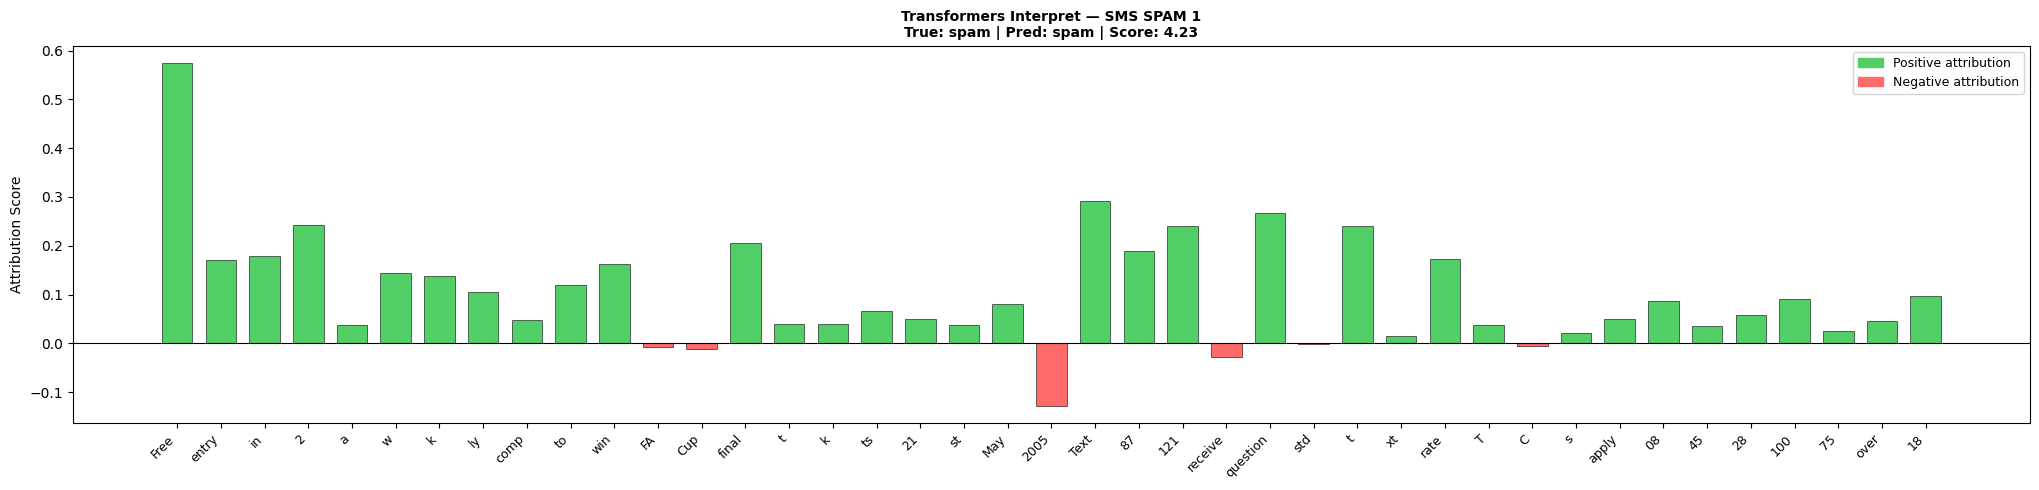

✅ Saved: /content/outputs_xai/fig12a_ti_spam1.png

⏭️ Tiếp tục Cell 15!


In [16]:
# ============================================================
# TRANSFORMERS INTERPRET — SMS SPAM 1 (Figure 12a + Table 13)
# ============================================================
print(f"📱 Đang giải thích SMS SPAM 1 (Transformers Interpret):")
print(f"   '{sms_spam_1}'\n")

# Chạy explainer
attrs_spam1 = cls_explainer(sms_spam_1, class_name='spam')
word_attrs1 = cls_explainer.word_attributions  # Dạng list: [(word, score), ...]

# Tính tổng attribution score từ word_attributions
attr_score1 = sum(score for word, score in word_attrs1)

pred_label_s1 = 'spam' if cls_explainer.predicted_class_index == 1 else 'ham'
print(f"   Predicted : {pred_label_s1}")
print(f"   True label: spam")

# In bảng (Table 13)
print_transformer_interpret_table(
    word_attrs1,
    sms_spam_1,
    true_label='spam (1)',
    pred_label=pred_label_s1,
    title="TABLE 13 — Transformers Interpret: SMS SPAM 1"
)

# Vẽ chart (Figure 12a)
plot_transformer_interpret(
    word_attrs1,
    sms_spam_1,
    true_label='spam',
    pred_label=pred_label_s1,
    attr_score=attr_score1,
    title="SMS SPAM 1",
    save_path='/content/outputs_xai/fig12a_ti_spam1.png'
)
print("\n⏭️ Tiếp tục Cell 15!")

📱 Đang giải thích SMS SPAM 2 (Transformers Interpret):
   'FreeMsg Hey there darling it s been 3 week now and no word back I d like some fun you up for still Tb ok XxX std chgs to send 1 50 rcv'


  TABLE 14 — Transformers Interpret: SMS SPAM 2
  True Label: spam (1) | Predicted: spam
  SMS: FreeMsg Hey there darling it s been 3 week now and no word back I...
  POSITIVE COEFFICIENTS               NEGATIVE COEFFICIENTS
  -----------------------------------------------------------------
  Word                        Value   Word                      Value
  -----------------------------------------------------------------
  'Free'                     0.3556   'std'                   -0.1069
  'Hey'                      0.3250   'b'                     -0.0679
  'X'                        0.3091   'send'                  -0.0350
  '1'                        0.2700   'to'                    -0.0297
  'Msg'                      0.2640   '50'                    -0.0138
  'darling'           

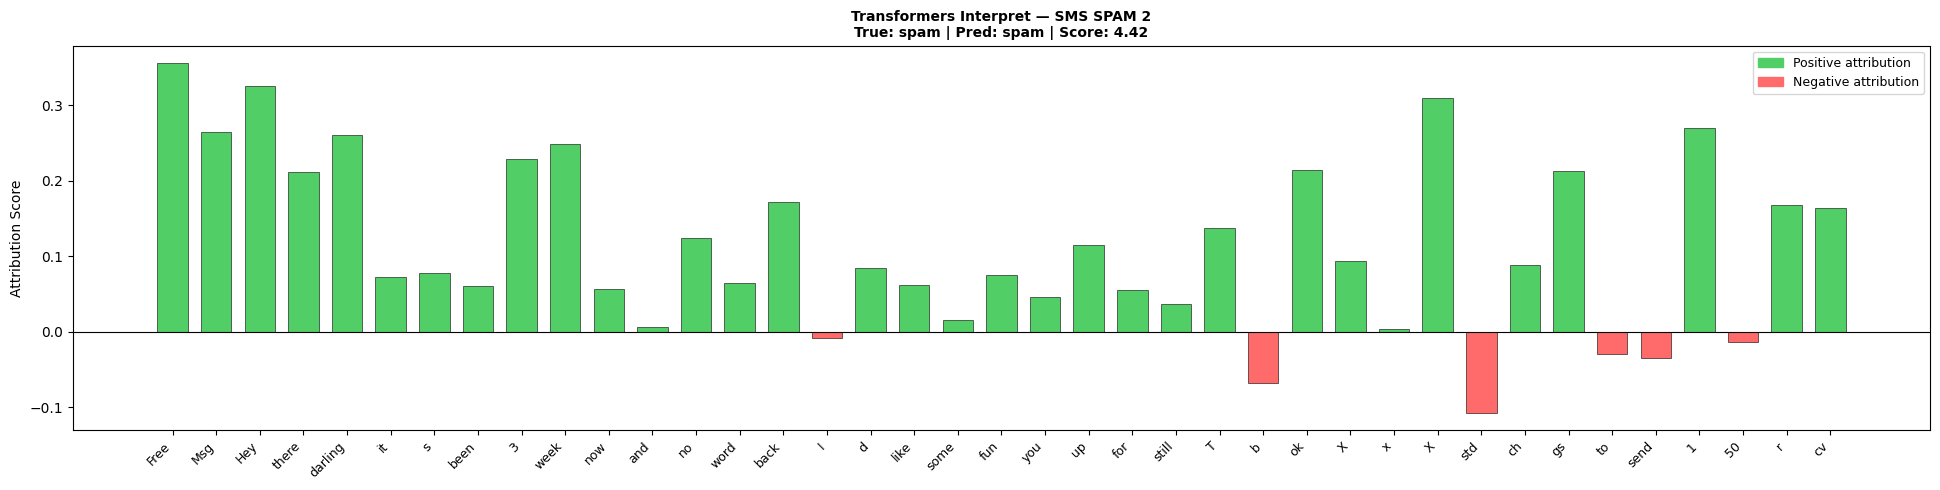

✅ Saved: /content/outputs_xai/fig12b_ti_spam2.png

⏭️ Tiếp tục Cell 16!


In [17]:
print(f"📱 Đang giải thích SMS SPAM 2 (Transformers Interpret):")
print(f"   '{sms_spam_2}'\n")

attrs_spam2 = cls_explainer(sms_spam_2, class_name='spam')
word_attrs2 = cls_explainer.word_attributions
pred_label_s2 = 'spam' if cls_explainer.predicted_class_index == 1 else 'ham'

# Tính tổng attribution score từ word_attributions
attr_score2 = sum(score for word, score in word_attrs2)

print_transformer_interpret_table(
    word_attrs2,
    sms_spam_2,
    true_label='spam (1)',
    pred_label=pred_label_s2,
    title="TABLE 14 — Transformers Interpret: SMS SPAM 2"
)

plot_transformer_interpret(
    word_attrs2,
    sms_spam_2,
    true_label='spam',
    pred_label=pred_label_s2,
    attr_score=attr_score2,
    title="SMS SPAM 2",
    save_path='/content/outputs_xai/fig12b_ti_spam2.png'
)
print("\n⏭️ Tiếp tục Cell 16!")

📱 Đang giải thích SMS HAM 1 (Transformers Interpret):
   'Go until jurong point crazy Available only in bugis n great world la e buffet Cine there got amore wat'


  TABLE 15 — Transformers Interpret: SMS HAM 1
  True Label: ham (0) | Predicted: ham
  SMS: Go until jurong point crazy Available only in bugis n great world...
  POSITIVE COEFFICIENTS               NEGATIVE COEFFICIENTS
  -----------------------------------------------------------------
  Word                        Value   Word                      Value
  -----------------------------------------------------------------
  'ore'                      0.4329   'great'                 -0.1075
  'crazy'                    0.4055   'there'                 -0.0932
  'n'                        0.4026   'is'                    -0.0887
  'wat'                      0.3378   'world'                 -0.0130
  'point'                    0.2957                                  
  'got'                      0.2114                       

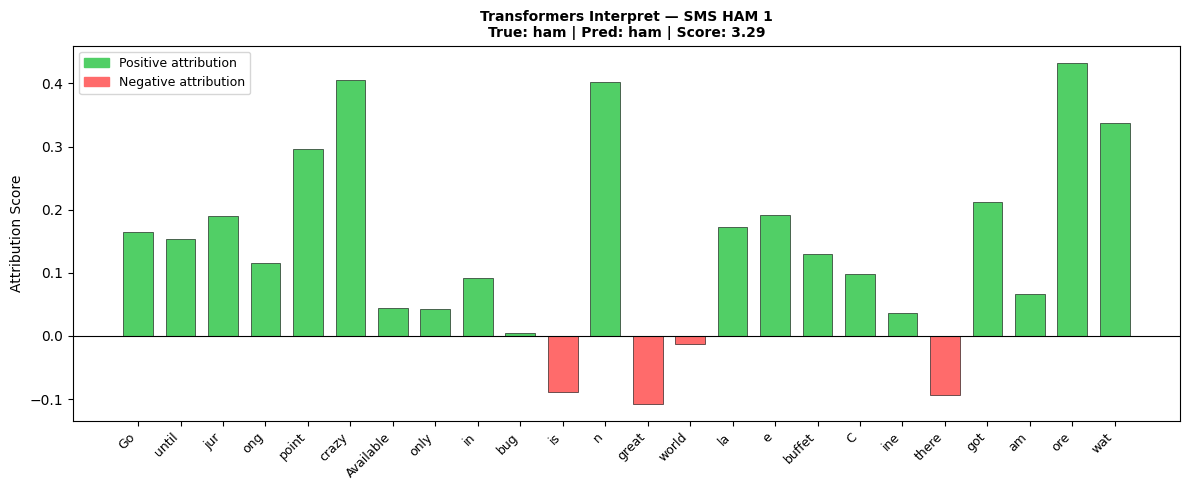

✅ Saved: /content/outputs_xai/fig13a_ti_ham1.png

⏭️ Tiếp tục Cell 17!


In [18]:
print(f"📱 Đang giải thích SMS HAM 1 (Transformers Interpret):")
print(f"   '{sms_ham_1}'\n")

attrs_ham1 = cls_explainer(sms_ham_1, class_name='ham')
word_attrs3 = cls_explainer.word_attributions
pred_label_h1 = 'spam' if cls_explainer.predicted_class_index == 1 else 'ham'

# Tính tổng attribution score từ word_attributions
attr_score3 = sum(score for word, score in word_attrs3)


print_transformer_interpret_table(
    word_attrs3,
    sms_ham_1,
    true_label='ham (0)',
    pred_label=pred_label_h1,
    title="TABLE 15 — Transformers Interpret: SMS HAM 1"
)

plot_transformer_interpret(
    word_attrs3,
    sms_ham_1,
    true_label='ham',
    pred_label=pred_label_h1,
    attr_score=attr_score3,
    title="SMS HAM 1",
    save_path='/content/outputs_xai/fig13a_ti_ham1.png'
)
print("\n⏭️ Tiếp tục Cell 17!")

📱 Đang giải thích SMS HAM 2 (Transformers Interpret):
   'Ok lar Joking wif u oni'


  TABLE 16 — Transformers Interpret: SMS HAM 2
  True Label: ham (0) | Predicted: ham
  SMS: Ok lar Joking wif u oni...
  POSITIVE COEFFICIENTS               NEGATIVE COEFFICIENTS
  -----------------------------------------------------------------
  Word                        Value   Word                      Value
  -----------------------------------------------------------------
  'w'                        0.6434   'Ok'                    -0.4726
  'i'                        0.4145   'lar'                   -0.2300
  'u'                        0.3103   'if'                    -0.0589
  'oking'                    0.1913                                  
  'J'                        0.0300                                  
  'on'                       0.0244                                  


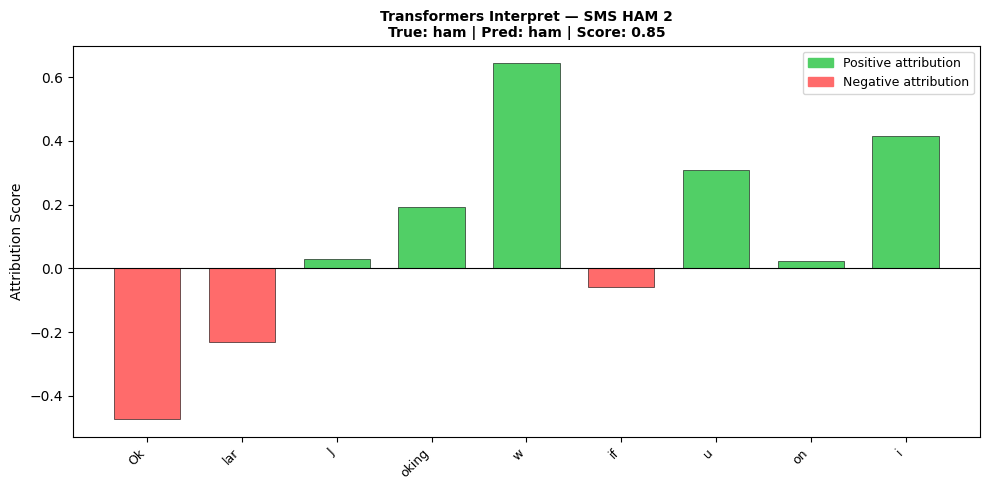

✅ Saved: /content/outputs_xai/fig13b_ti_ham2.png

⏭️ Tiếp tục Cell 18!


In [19]:
print(f"📱 Đang giải thích SMS HAM 2 (Transformers Interpret):")
print(f"   '{sms_ham_2}'\n")

attrs_ham2 = cls_explainer(sms_ham_2, class_name='ham')
word_attrs4 = cls_explainer.word_attributions
pred_label_h2 = 'spam' if cls_explainer.predicted_class_index == 1 else 'ham'

# Tính tổng attribution score từ word_attributions
attr_score4 = sum(score for word, score in word_attrs4)

print_transformer_interpret_table(
    word_attrs4,
    sms_ham_2,
    true_label='ham (0)',
    pred_label=pred_label_h2,
    title="TABLE 16 — Transformers Interpret: SMS HAM 2"
)

plot_transformer_interpret(
    word_attrs4,
    sms_ham_2,
    true_label='ham',
    pred_label=pred_label_h2,
    attr_score=attr_score4,
    title="SMS HAM 2",
    save_path='/content/outputs_xai/fig13b_ti_ham2.png'
)
print("\n⏭️ Tiếp tục Cell 18!")

In [20]:
import shutil
from google.colab import files

shutil.make_archive('/content/Stage3_XAI_outputs', 'zip', '/content/outputs_xai')

print("📁 Các file đã tạo:")
for f in sorted(os.listdir('/content/outputs_xai')):
    size = os.path.getsize(f'/content/outputs_xai/{f}')
    print(f"   {f}  ({size/1024:.0f} KB)")

files.download('/content/Stage3_XAI_outputs.zip')
print("\n✅ HOÀN THÀNH GIAI ĐOẠN 3 — XAI!")
print("🎉 Đã xong cả 3 giai đoạn!")

📁 Các file đã tạo:
   fig10ab_lime_spam1.png  (67 KB)
   fig10cd_lime_spam2.png  (60 KB)
   fig11ab_lime_ham1.png  (61 KB)
   fig11cd_lime_ham2.png  (43 KB)
   fig12a_ti_spam1.png  (81 KB)
   fig12b_ti_spam2.png  (76 KB)
   fig13a_ti_ham1.png  (64 KB)
   fig13b_ti_ham2.png  (44 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ HOÀN THÀNH GIAI ĐOẠN 3 — XAI!
🎉 Đã xong cả 3 giai đoạn!
